## import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import mean_squared_error

In [2]:
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

### Import DataSet

In [3]:
df = pd.read_csv(r"C:\Users\ryana\Downloads\DataSet\PJME_hourly.csv")

In [4]:
df.sample(5)

,Datetime,PJME_MW
95417,2012-02-11 17:00:00,33249.0
25586,2004-01-30 09:00:00,41629.0
80756,2011-10-14 17:00:00,31591.0
128603,2016-04-29 12:00:00,29412.0
125507,2016-09-05 12:00:00,29427.0


In [5]:
df.shape

(145366, 2)

In [6]:
df['PJME_MW'].describe()

count    145366.000000
mean      32080.222831
std        6464.012166
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64

In [7]:
df = df.set_index('Datetime') # change column datetime to index 
df.index = pd.to_datetime(df.index) # change data type to datetime

In [8]:
df.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


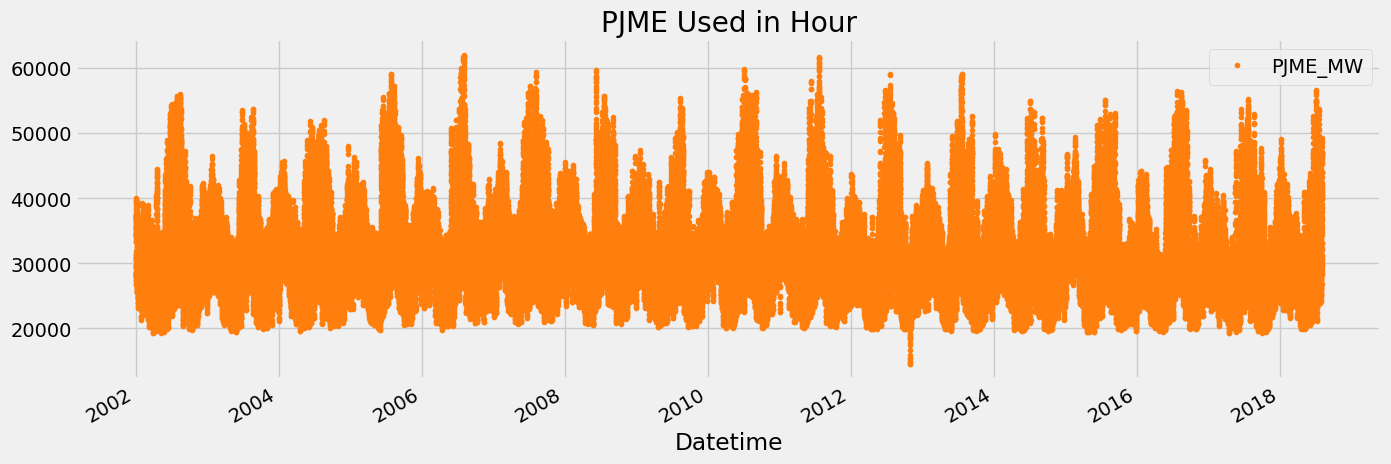

In [9]:
df.plot(
    style='.',
    figsize=(15,5),
    color=color_pal[1],
    title= 'PJME Used in Hour'
)
plt.show()

### Outlier Analysis and Removal

#### Z-Score Checking

In [10]:
# Calculating Z-score value
from scipy.stats import zscore

df['Z-Score'] = zscore(df['PJME_MW'])

In [11]:
df.sample(5)

,PJME_MW,Z-Score
Datetime,,
2002-05-14 01:00:00,23573.0,-1.316095
2017-06-01 06:00:00,23645.0,-1.304956
2008-10-14 22:00:00,32369.0,0.044675
2008-03-01 22:00:00,34185.0,0.325616
2013-06-17 01:00:00,27100.0,-0.770456


In [17]:
df.shape

(145366, 2)

In [ ]:
df[df['Z-Score'].abs() > 1]

In [ ]:
# select outlier (value Z-Score > 3 or < -3)
outliers = df[df['Z-Score'].abs() > 3]
print("Outliers Detected:\n", outliers)

#### BoxPlot & Histogram Viz

<Axes: ylabel='Frequency'>

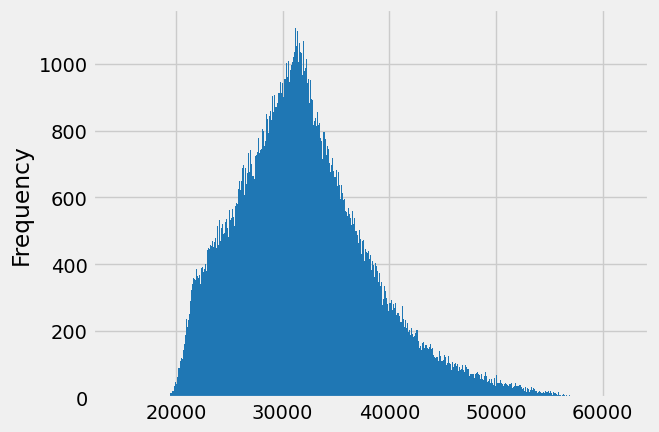

In [20]:
df['PJME_MW'].plot(
    kind='hist',
    bins=500,
    color=color_pal[0]
)

from the histogram, as we can see the data has potential outlier in value < 19000 also potential in value > 55000.

What dou you think?

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

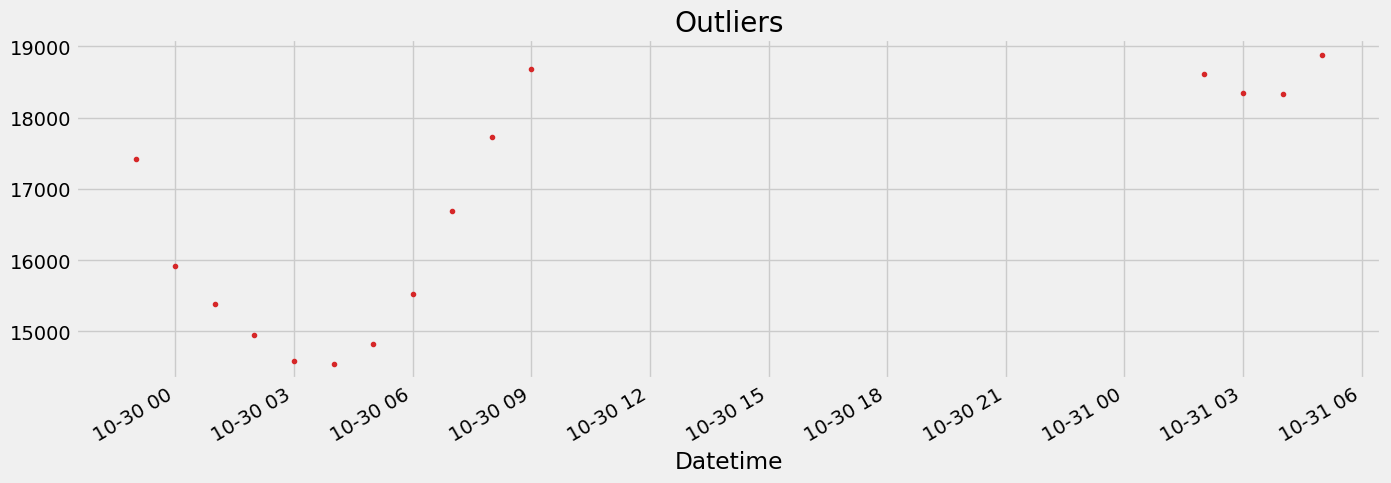

In [37]:
# select and vizualize using plot where value less than 19000
df.query('PJME_MW < 19000')['PJME_MW']\
    .plot(
        style='.',
        figsize=(15,5),
        color=color_pal[3],
        title='Outliers'
    )

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

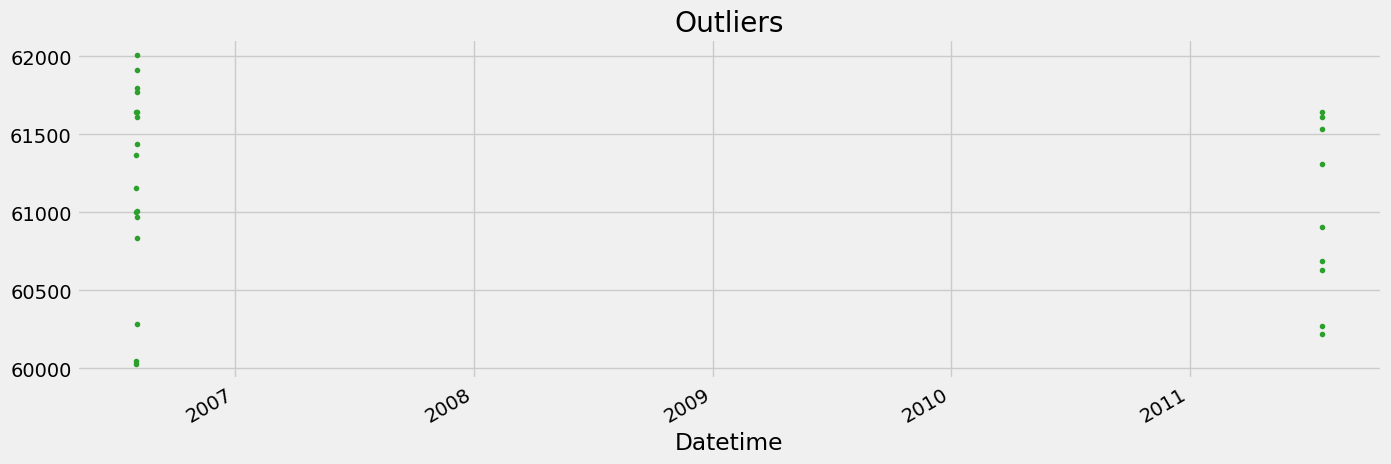

In [34]:
# select and vizualize using plot where value more than 60000
df.query('PJME_MW > 60000')['PJME_MW']\
    .plot(
        style='.',
        figsize=(15,5),
        color=color_pal[2],
        title='Outliers'
    )

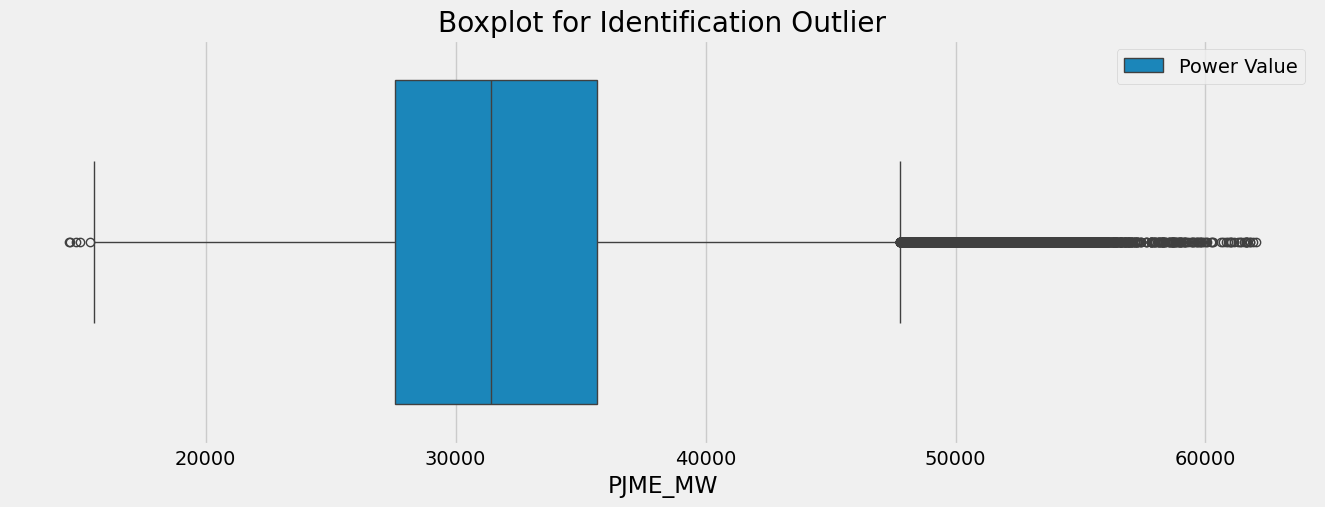

In [32]:
# Visualisasi menggunakan Boxplot
plt.figure(figsize=(15, 5))
sns.boxplot(x=df['PJME_MW'], label='Power Value')
plt.title('Boxplot for Identification Outlier')
plt.show()

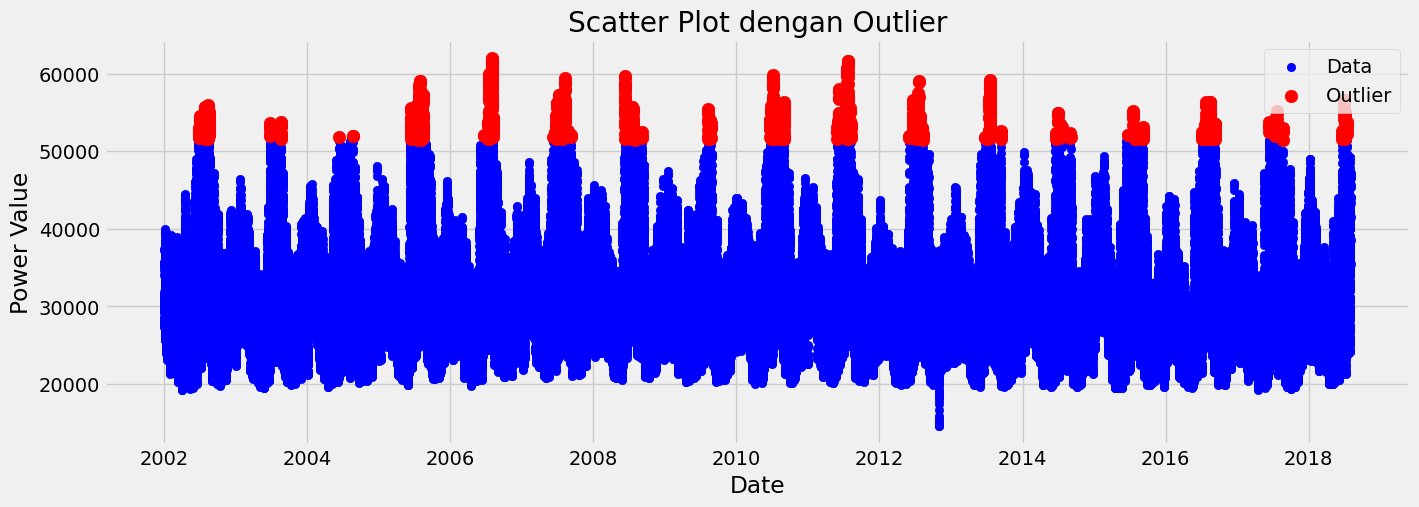

In [36]:
# Visualisasi menggunakan Scatter Plot
plt.figure(figsize=(15, 5))
plt.scatter(df.index, df['PJME_MW'], label='Data', color='blue')

# Menambahkan outlier ke plot
plt.scatter(outliers.index, outliers['PJME_MW'], color='red', label='Outlier', s=80)
plt.title('Scatter Plot dengan Outlier')
plt.xlabel('Date')
plt.ylabel('Power Value')
plt.legend()
plt.show()

In [39]:
# remove outlier and save new data
df = df[df['PJME_MW'] >= 19000]

In [58]:
df.shape

(144990, 2)

In [59]:
df = df.drop('Z-Score', axis=1)

### Review Train/Test Split

In [60]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2016']

In [61]:
test.head()

,PJME_MW
Datetime,
2015-01-01 00:00:00,32802.0
2015-12-31 01:00:00,24305.0
2015-12-31 02:00:00,23156.0
2015-12-31 03:00:00,22514.0
2015-12-31 04:00:00,22330.0


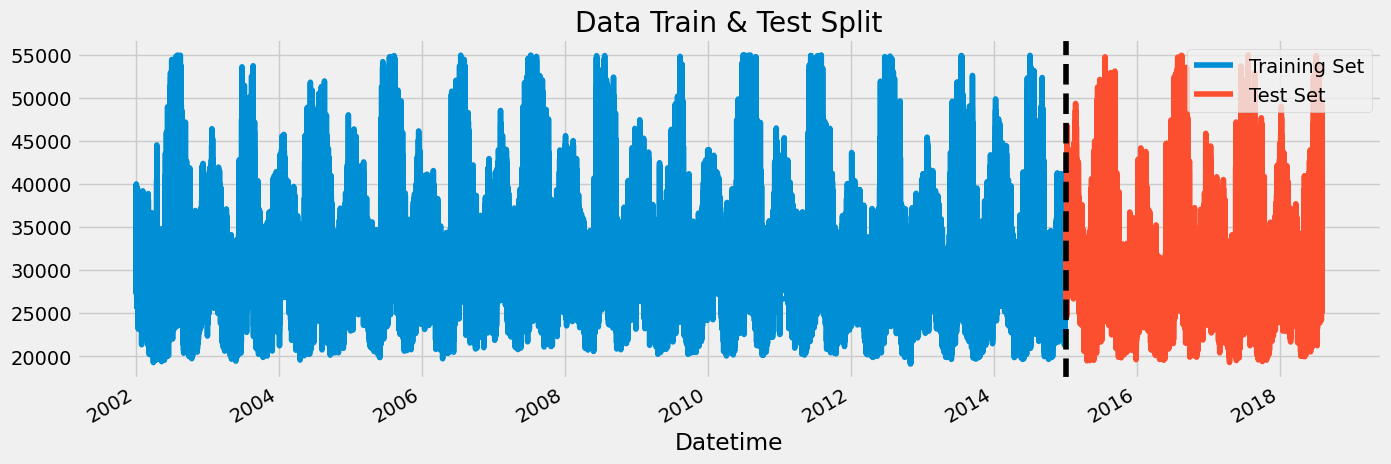

In [62]:
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax, label='Training Set', title='Data Train & Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

### Time Series Cross Validation

In [63]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

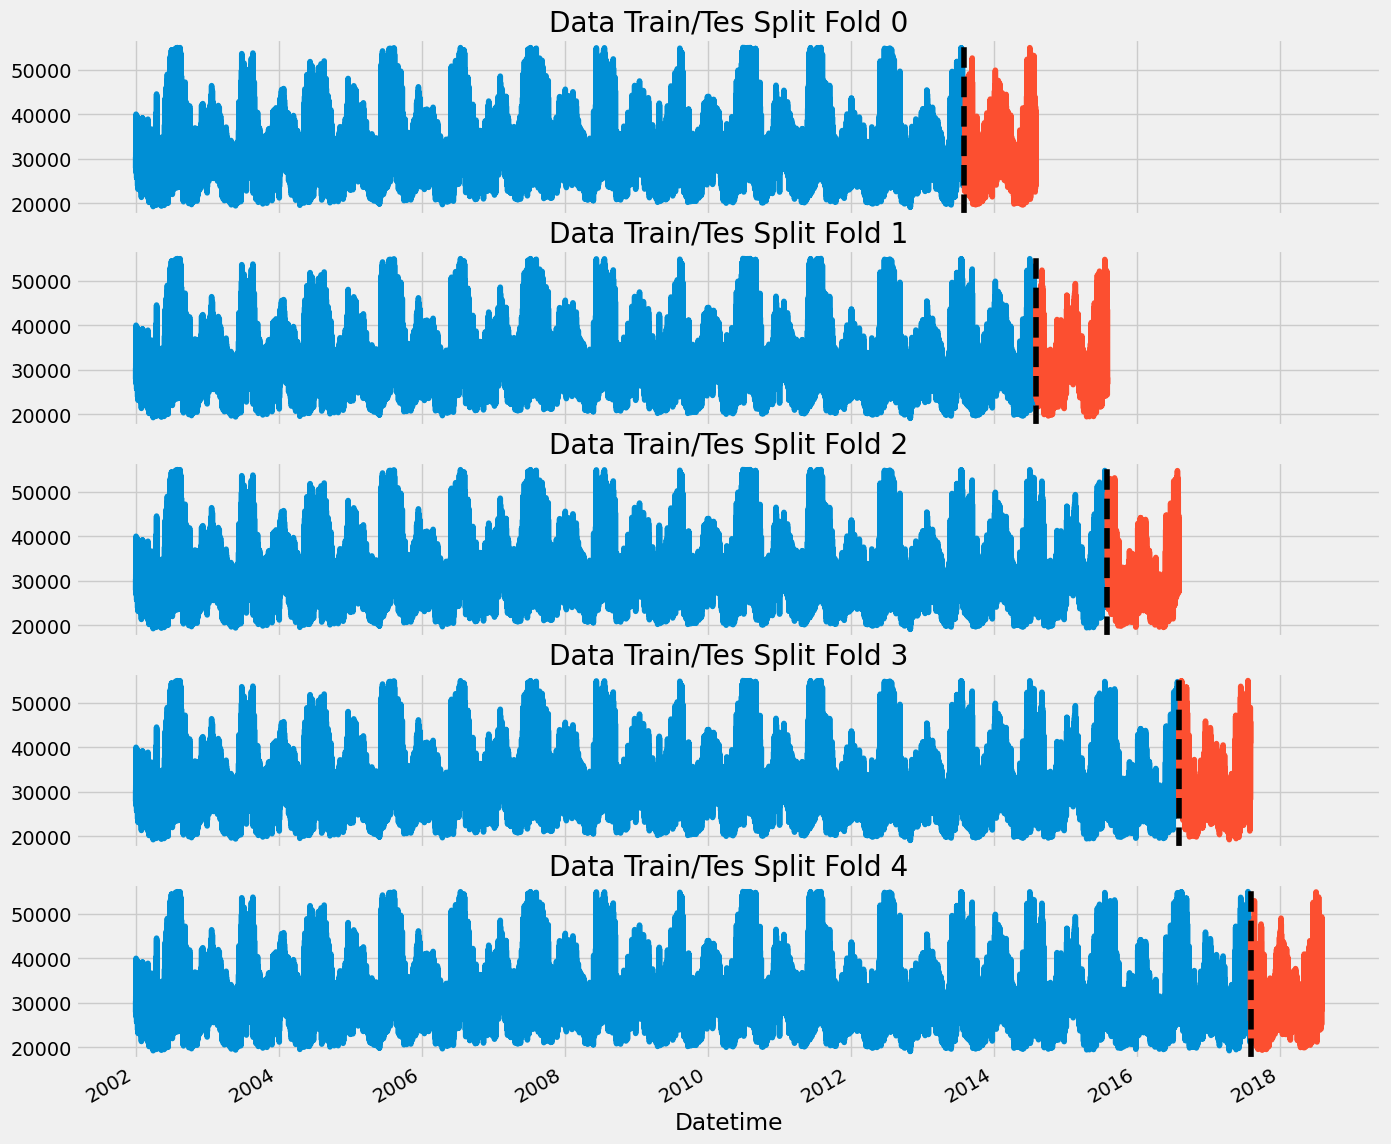

In [69]:
fig, axs = plt.subplots(5, 1, figsize=(15,15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['PJME_MW'].plot(ax=axs[fold],
                         label='Training Set',
                          title=f'Data Train/Tes Split Fold {fold}'
                         )
    test['PJME_MW'].plot(ax=axs[fold],
                         label='Test Set'
                        )
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1

plt.show()

### Forecasting Horizon Explained
The forecast horizon is the length of time into the future for which forecasts are to be prepared. These generally vary from short-term forecasting horizons (less than three months) to long-term horizons (more than two years).

In [71]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

In [73]:
df.sample(6)

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2002-02-02 16:00:00,28072.0,16,5,1,2,2002,33,2,5
2009-03-27 19:00:00,29487.0,19,4,1,3,2009,86,27,13
2007-12-05 13:00:00,39266.0,13,2,4,12,2007,339,5,49
2017-10-24 07:00:00,27812.0,7,1,4,10,2017,297,24,43
2008-10-28 09:00:00,34392.0,9,1,4,10,2008,302,28,44
2008-12-29 00:00:00,26982.0,0,0,4,12,2008,364,29,1


### Lag Features
What was the target (x) days in the past.

In [72]:
def add_lags(df):
    target_map = df['PJME_MW'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('364 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df

In [74]:
df = add_lags(df)

In [75]:
df.sample(10)

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3
Datetime,,,,,,,,,,,,
2006-10-09 01:00:00,22786.0,1,0,4,10,2006,282,9,41,23316.0,22275.0,22735.0
2017-05-07 14:00:00,24451.0,14,6,2,5,2017,127,7,18,23031.0,30531.0,26471.0
2010-07-31 22:00:00,36352.0,22,5,3,7,2010,212,31,30,38354.0,38242.0,44910.0
2002-03-07 03:00:00,23832.0,3,3,1,3,2002,66,7,10,NaN,NaN,NaN
2010-05-16 11:00:00,26208.0,11,6,2,5,2010,136,16,19,26402.0,27046.0,26773.0
2003-07-29 06:00:00,28018.0,6,1,3,7,2003,210,29,31,35759.0,NaN,NaN
2016-09-12 11:00:00,32962.0,11,0,3,9,2016,256,12,37,29810.0,29637.0,31477.0
2005-03-22 17:00:00,30934.0,17,1,1,3,2005,81,22,12,32351.0,29827.0,33481.0
2011-02-19 02:00:00,23625.0,2,5,1,2,2011,50,19,7,28591.0,30605.0,29639.0


In [80]:
df[df[['lag1', 'lag2', 'lag3']].isna().any(axis=1)] #Or method

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3
Datetime,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-07-16 18:00:00,53352.0,18,0,3,7,2018,197,16,29,47118.0,47275.0,NaN
2018-07-19 17:00:00,43598.0,17,3,3,7,2018,200,19,29,NaN,49078.0,42554.0
2018-07-23 15:00:00,44334.0,15,0,3,7,2018,204,23,30,43471.0,NaN,46278.0


In [82]:
df[df[['lag1', 'lag2', 'lag3']].isna().all(axis=1)] # AND Method

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3
Datetime,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,1,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2014-07-15 17:00:00,45532.0,17,1,3,7,2014,196,15,29,NaN,NaN,NaN
2014-07-16 16:00:00,41826.0,16,2,3,7,2014,197,16,29,NaN,NaN,NaN
2014-11-02 02:00:00,22935.0,2,6,4,11,2014,306,2,44,NaN,NaN,NaN


In [101]:
df[['lag1', 'lag2', 'lag3']].ffill()

,lag1,lag2,lag3
Datetime,,,
2002-01-01 01:00:00,NaN,NaN,NaN
2002-01-01 02:00:00,NaN,NaN,NaN
2002-01-01 03:00:00,NaN,NaN,NaN
2002-01-01 04:00:00,NaN,NaN,NaN
2002-01-01 05:00:00,NaN,NaN,NaN
...,...,...,...
2018-08-02 20:00:00,42256.0,41485.0,38804.0
2018-08-02 21:00:00,41210.0,40249.0,38748.0
2018-08-02 22:00:00,39525.0,38698.0,37330.0


### Train using Cross Validation

In [83]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

In [102]:
fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year',
                'lag1','lag2','lag3']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:squarederror',
                           max_depth=3,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:32622.74550	validation_1-rmse:31959.12605
[100]	validation_0-rmse:12483.71678	validation_1-rmse:11995.66525
[200]	validation_0-rmse:5691.48707	validation_1-rmse:5408.71833
[300]	validation_0-rmse:3805.74281	validation_1-rmse:3881.30073
[400]	validation_0-rmse:3364.52286	validation_1-rmse:3708.89977
[457]	validation_0-rmse:3279.88881	validation_1-rmse:3709.92606
[0]	validation_0-rmse:32571.86843	validation_1-rmse:32102.72023
[100]	validation_0-rmse:12467.83180	validation_1-rmse:12257.15423
[200]	validation_0-rmse:5709.25526	validation_1-rmse:5648.73581
[300]	validation_0-rmse:3842.07185	validation_1-rmse:3883.36522
[400]	validation_0-rmse:3410.18228	validation_1-rmse:3543.94523
[500]	validation_0-rmse:3288.36425	validation_1-rmse:3479.44488
[600]	validation_0-rmse:3232.88608	validation_1-rmse:3449.81904
[700]	validation_0-rmse:3194.43248	validation_1-rmse:3438.83185
[800]	validation_0-rmse:3161.09853	validation_1-rmse:3409.33656
[900]	validation_0-rmse:3133.18803	v

In [103]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3716.3213
Fold scores:[np.float64(3706.090693037762), np.float64(3375.6826213244462), np.float64(3494.394013527293), np.float64(4028.606980070002), np.float64(3976.8321830502373)]


### Future Prediction
- Retraining on all data
- To Predict the future we need an emtpy dataframe for future date ranges.
- Run those dates through our feature creation code + lag creation

In [104]:
# Retrain on all data
df = create_features(df)

In [105]:
df.sample(10)

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,isFuture
Datetime,,,,,,,,,,,,,
2007-04-22 03:00:00,21322.0,3,6,2,4,2007,112,22,16,21771.0,21165.0,20343.0,False
2009-01-06 12:00:00,37867.0,12,1,1,1,2009,6,6,2,32847.0,35315.0,33794.0,False
2017-09-17 06:00:00,23547.0,6,6,3,9,2017,260,17,37,23559.0,23860.0,21278.0,False
2007-08-19 21:00:00,32805.0,21,6,3,8,2007,231,19,33,44222.0,46099.0,33035.0,False
2018-07-04 01:00:00,36317.0,1,2,3,7,2018,185,4,27,29763.0,32757.0,33858.0,False
2010-02-10 02:00:00,30188.0,2,2,1,2,2010,41,10,6,25261.0,31190.0,33060.0,False
2005-03-25 11:00:00,33160.0,11,4,1,3,2005,84,25,12,31664.0,31198.0,29080.0,False
2009-04-27 14:00:00,40189.0,14,0,2,4,2009,117,27,18,32781.0,33689.0,31651.0,False
2011-02-18 03:00:00,23278.0,3,4,1,2,2011,49,18,7,29016.0,30959.0,31004.0,False


#### XGB Model

In [106]:
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year',
            'lag1','lag2','lag3']
TARGET = 'PJME_MW'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',    
                       n_estimators=1000,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=100)

[0]	validation_0-rmse:32322.05515
[100]	validation_0-rmse:12389.18117
[200]	validation_0-rmse:5714.90758
[300]	validation_0-rmse:3920.12768
[400]	validation_0-rmse:3514.02558
[500]	validation_0-rmse:3401.59429
[600]	validation_0-rmse:3350.60561
[700]	validation_0-rmse:3315.18992
[800]	validation_0-rmse:3285.37109
[900]	validation_0-rmse:3258.82457
[999]	validation_0-rmse:3233.71526


,objective,'reg:squarederror'
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [90]:
df.index.max()

Timestamp('2018-08-03 00:00:00')

#### Create future dataframe

In [107]:
future = pd.date_range('2018-08-03','2019-08-01', freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [108]:
future_w_features = df_and_future.query('isFuture').copy()

In [109]:
future_w_features

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,isFuture
2018-08-03 00:00:00,NaN,0,4,3,8,2018,215,3,31,33539.0,32094.0,31695.0,True
2018-08-03 01:00:00,NaN,1,4,3,8,2018,215,3,31,30781.0,29503.0,29128.0,True
2018-08-03 02:00:00,NaN,2,4,3,8,2018,215,3,31,29015.0,27712.0,27373.0,True
2018-08-03 03:00:00,NaN,3,4,3,8,2018,215,3,31,27884.0,26535.0,26233.0,True
2018-08-03 04:00:00,NaN,4,4,3,8,2018,215,3,31,27223.0,25870.0,25643.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-31 20:00:00,NaN,20,2,3,7,2019,212,31,31,46912.0,39352.0,40243.0,True
2019-07-31 21:00:00,NaN,21,2,3,7,2019,212,31,31,45985.0,38699.0,39183.0,True
2019-07-31 22:00:00,NaN,22,2,3,7,2019,212,31,31,44094.0,37346.0,37759.0,True
2019-07-31 23:00:00,NaN,23,2,3,7,2019,212,31,31,40666.0,34555.0,34641.0,True


### Predict the Feature

In [110]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])

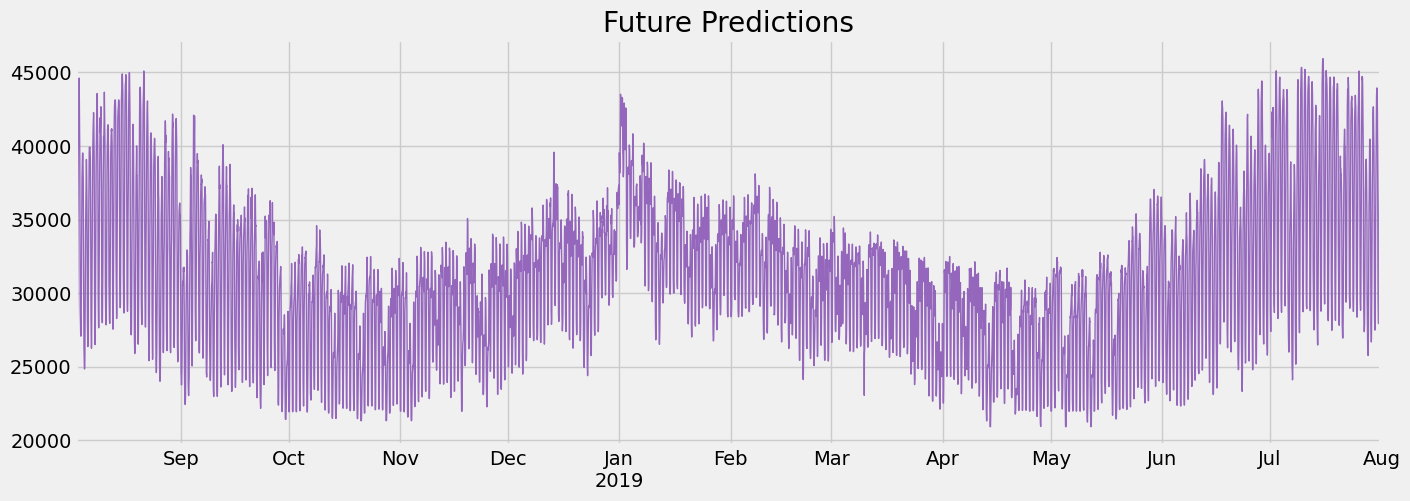

In [111]:
future_w_features['pred'].plot(figsize=(15, 5),
                               color=color_pal[4],
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

In [112]:
future_w_features

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,isFuture,pred
2018-08-03 00:00:00,NaN,0,4,3,8,2018,215,3,31,33539.0,32094.0,31695.0,True,31610.712891
2018-08-03 01:00:00,NaN,1,4,3,8,2018,215,3,31,30781.0,29503.0,29128.0,True,29377.367188
2018-08-03 02:00:00,NaN,2,4,3,8,2018,215,3,31,29015.0,27712.0,27373.0,True,28305.091797
2018-08-03 03:00:00,NaN,3,4,3,8,2018,215,3,31,27884.0,26535.0,26233.0,True,27675.033203
2018-08-03 04:00:00,NaN,4,4,3,8,2018,215,3,31,27223.0,25870.0,25643.0,True,27372.636719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-07-31 20:00:00,NaN,20,2,3,7,2019,212,31,31,46912.0,39352.0,40243.0,True,42625.421875
2019-07-31 21:00:00,NaN,21,2,3,7,2019,212,31,31,45985.0,38699.0,39183.0,True,41927.367188
2019-07-31 22:00:00,NaN,22,2,3,7,2019,212,31,31,44094.0,37346.0,37759.0,True,40653.828125
2019-07-31 23:00:00,NaN,23,2,3,7,2019,212,31,31,40666.0,34555.0,34641.0,True,37731.074219
